# Implementation of MSM

Start by copying the code implementing consumption-savings model from  `lab5/egm.ipynb`, and make the following modifications:
- move `solve_egm` into the `deaton` model class to make it a class method
    * make sure to adjust the indent in each line!
    * effectively no change to the code is needed, only perhaps change first argument from *model* to *self*, yet the exact word used does not matter, so it should work as is
- also move `solve_plot`, `euler_residual`, `accuracy`, and `simulator` into the class in exactly the same way


In [30]:
# Copy the modified consumption-savings model here
import numpy as np
import matplotlib.pyplot as plt
from scipy import interpolate
from scipy.stats import lognorm


class deaton():
  '''Implementation of the stochastic Deaton consumption-savings problem with random income.'''

  def __init__(self, Mbar=10, ngrid=50, nquad=10, interpolation='linear', beta=.9, R=1.05, sigma=1.):
    '''Object creator for the stochastic consumption-savings model'''
    self.beta = beta                        # Discount factor
    self.R = R                              # Gross interest
    self.sigma = sigma                      # Param in log-normal income distribution
    self.Mbar = Mbar                        # Upper bound on wealth
    self.ngrid = ngrid                      # Number of grid points in the state space
    self.nquad = nquad                      # Number of quadrature points
    self.interpolation = interpolation      # type of interpolation, see below
                                            # state and choice space grids, as well as quadrature points and weights are set with setter functions below

  def __repr__(self):
    '''String representation for the model'''
    return 'Deaton model with beta={:1.3f}, sigma={:1.3f}, gross return={:1.3f}\nGrids: state {} points up to {:1.1f}, quadrature {} points\nThe model is {}solved.'\
           .format(self.beta,self.sigma,self.R,self.ngrid,self.Mbar,self.nquad,'' if hasattr(self,'solution') else 'not ')

  @property
  def ngrid(self):
    '''Property getter for the ngrid parameter'''
    return self.__ngrid

  @ngrid.setter
  def ngrid(self, ngrid):
    '''Property setter for the ngrid parameter'''
    self.__ngrid = ngrid
    epsilon = np.finfo(float).eps                      # smallest positive float number difference
    self.grid = np.linspace(epsilon, self.Mbar, ngrid) # grid for state space

  @property
  def sigma(self):
    '''Property getter for the sigma parameter'''
    return self.__sigma

  @sigma.setter
  def sigma(self, sigma):
    '''Property setter for the sigma parameter'''
    self.__sigma = sigma
    self.__quadrature_setup()     # update quadrature points and weights

  @property
  def nquad(self):
    '''Property getter for the number of quadrature points'''
    return self.__nquad

  @nquad.setter
  def nquad(self, nquad):
    '''Property setter for the number of quadrature points'''
    self.__nquad = nquad
    self.__quadrature_setup()     # update quadrature points and weights

  def __quadrature_setup(self):
    '''Internal function to set up quadrature points and weights,
        depends on sigma and nquad, therefore called from the property setters
        '''
    try:
      # quadrature points and weights for log-normal distribution
      self.quadp, self.quadw = np.polynomial.legendre.leggauss(self.__nquad) # Gauss-Legendre for [-1,1]
      self.quadp = (self.quadp + 1) / 2                                      # rescale to [0,1]
      self.quadp = lognorm.ppf(self.quadp, self.__sigma)                     # inverse cdf
      self.quadw /= 2                                                        # rescale weights as well
    
    except (AttributeError):
      # when __nquad or __sigma are not yet set
      pass

  def utility(self, c):
    '''Utility function'''
    # log utility
    
    return np.log(c)
  
  def marginal_utility(self, c):
    '''Marginal utility function'''
    
    return 1/c

  def inverse_marginal_utility(self, u):
    '''Marginal utility function'''
  
    return 1/u

  def next_period_wealth(self, M, c, y):
    '''Next period budget'''
    if self.nquad > 1:
      # stochastic income case
      return self.R * (M - c) + np.zeros(shape=y.shape) + y                       # next period wealth
    else:
      # use np.zeros(shape=y.shape) in place of y to revert the nquad=0 case for no income
      return self.R * (M - c) + np.zeros(shape=y.shape) # next period wealth without income

  def interp_func(self, x, f):
    '''Returns the interpolation function for given data'''
    if self.interpolation == 'linear':
      return interpolate.interp1d(x, f, kind='slinear', fill_value="extrapolate")
    elif self.interpolation == 'quadratic':
      return interpolate.interp1d(x, f, kind='quadratic', fill_value="extrapolate")
    elif self.interpolation == 'cubic':
      return interpolate.interp1d(x, f, kind='cubic', fill_value="extrapolate")
    elif self.interpolation == 'polynomial':
      p = np.polynomial.polynomial.polyfit(x, f, self.ngrid_state - 1)
      return lambda x: np.polynomial.polynomial.polyval(x, p)
    else:
      print('Unknown interpolation type')
      return None

  def solve_egm(self, maxiter=500, tol=1e-4, callback=None):
    '''Solves the model using EGM (successive approximations of efficient Coleman-Reffet operator)
          Callback function is invoked at each iteration with keyword arguments.
      '''
    # grid on savings using the model grid parameters
    A = np.linspace(0, self.Mbar, self.ngrid + 1)  

    # linear interpolation function
    interp = lambda x, f: interpolate.interp1d(x, f, kind='slinear', fill_value="extrapolate")
    # initial policy and value function
    c0 = interp([0, self.Mbar], [0, self.Mbar])
    V0 = self.utility(self.grid)
    # main iteration loop
    for iter in range(maxiter):
      # EGM step
      # matrix with A in axis=0, y/quadpoints in axis=1
      M1 = self.next_period_wealth(A[:, np.newaxis], 0, self.quadp[np.newaxis, :])
      # consumption at next period wealth, 3-dim array
      c1 = np.maximum(c0(M1), self.grid[0])
      # marginal utility in the RHS
      mu = self.marginal_utility(c1)
      # RHS of Euler equation
      RHS =  self.beta*self.R * np.dot(mu, self.quadw)
      # Initialize new consumption and wealth arrays
      c = np.empty(self.ngrid + 1, dtype=float)
      M = np.empty(self.ngrid + 1, dtype=float)
      # Set first elements in both to zero (credit constrained region)
      c[0], M[0] = 0,0
      # current period consumption (vector starting from the second element)
      c[1:] = self.inverse_marginal_utility(RHS[1:])
      # vector of endogenous points on M (starting from second element)
      M[1:] = c[1:] + A[1:]
      # updated policy function
      c1 = interp(M, c)
      # vector representation of policy function
      c1grid = c1(self.grid)
      # ALSO compute the value function
      # matrix of next period wealth, states in axis=0, quadpoint in axis=1
      M1 = self.next_period_wealth(self.grid[:, np.newaxis], c1grid[:, np.newaxis], self.quadp[np.newaxis, :])
      # interpolcation for the value function
      interfunc = self.interp_func(self.grid, V0)
      # value function at next period wealth
      V = interfunc(M1)
      # expected value function, vector
      EV = np.dot(V, self.quadw)
      # maximand of Bellman equation, column-vector
      V1 = self.utility(c1grid) + self.beta * EV
      # convergence check
      err = np.amax(np.abs(c1grid - c0(self.grid)))
      # callback for making plots
      if callback: callback(iter=iter, model=self, value=V1, policy=c1grid, err=err)
      if err < tol:
        break   # converged!
                # prepare for the next iteration
      c0, V0 = c1, V1
    else:
                # when iter went up to maxiter
      raise RuntimeError('No convergence: maximum number of iterations achieved!')
                # save the model solution to the object
    self.solution = {'value': V1, 'policy': c1grid, 'solver': 'egm'}
    # return value and consumption over fixed grid for plotting
    return V1, c1grid


  def solve_plot(self, **kvarg):
    '''Illustrate solution
          Inputs: solver (string), and any inputs to the solver
      '''
    fig1, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 8))
    ax1.grid(visible=True, which='both', color='0.65', linestyle='-')
    ax2.grid(visible=True, which='both', color='0.65', linestyle='-')
    ax1.set_title('Value function convergence')
    ax2.set_title('Policy function convergence')
    ax1.set_xlabel('Wealth, M')
    ax2.set_xlabel('Wealth, M')
    ax1.set_ylabel('Value function')
    ax2.set_ylabel('Policy function')

    def callback(**kwargs):
      print('|', end='')
      grid = kwargs['model'].grid
      v = kwargs['value']
      c = kwargs['policy']
      ax1.plot(grid[1:], v[1:], color='k', alpha=0.25)
      ax2.plot(grid, c, color='k', alpha=0.25)

    V, c = solve_egm(self, callback=callback, **kvarg)
    # add solutions
    ax1.plot(self.grid[1:], V[1:], color='r', linewidth=2.5)
    ax2.plot(self.grid, c, color='r', linewidth=2.5)
    plt.show()

  def simulator(self, init_wealth=1, T=10, seed=None, plot=True):
    '''Simulation of the model for given number of periods from given initial conditions'''
    assert hasattr(self, 'solution'), 'Need to solve the model before simulating!'
    if seed != None:
      # fix the seed if asked
      np.random.seed(seed)
    # flat np array of initial wealth
    init_wealth = np.asarray(init_wealth).ravel()
    # number of trajectories to simulate
    N = init_wealth.size
    # initialize storage for simulated data
    sim = {'M': np.empty((N, T + 1)), 'c': np.empty((N, T + 1))}
    # initial wealth in the first column
    sim['M'][:, 0] = init_wealth
    # interpolation function for policy function
    inter = self.interp_func(self.grid, self.solution['policy'])
    for t in range(T + 1):
      # optimal consumption in period t
      sim['c'][:, t] = inter(sim['M'][:, t])
      if t < T:
        # draw random income
        y = lognorm.rvs(self.sigma, size=N)
        # next period wealth
        sim['M'][:, t + 1] = self.next_period_wealth(sim['M'][:, t], sim['c'][:, t], y)
    if plot:
      fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 6))
      ax1.set_title('Simulated wealth and consumption trajectories')
      ax1.set_ylabel('Wealth')
      ax2.set_ylabel('Consumption')
      ax2.set_xlabel('Time period in the simulation')
      for ax in (ax1, ax2):
        ax.grid(visible=True, which='both', color='0.95', linestyle='-')
      for i in range(N):
        ax1.plot(sim['M'][i, :], alpha=0.75)
        ax2.plot(sim['c'][i, :], alpha=0.75)
      plt.show()
    # return simulated data
    return sim




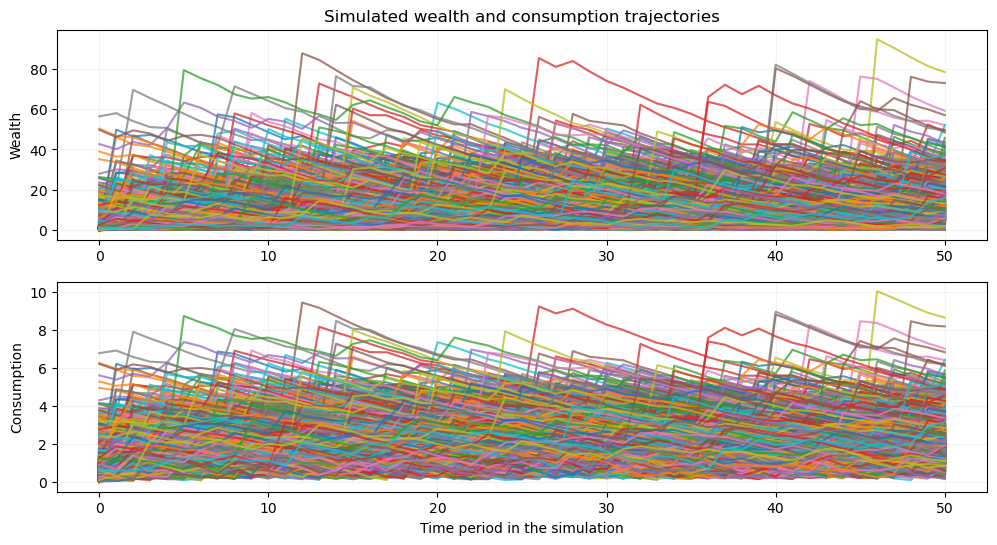

In [31]:
# Simulate a dataset that will be used for estimation
# (and check that the model code is working correctly)
model = deaton(beta=0.92,Mbar=50,ngrid=100)
model.solve_egm()
np.random.seed(14325)      # fix seed for initial draws
Nobs = 10000 # number of observations to simulate
nT = 50 # number of time periods to simulate
init_wealth = np.exp(np.random.randn(Nobs)) # draw initial wealth
np.random.seed(15920) # fix seed for simulations
data = model.simulator(init_wealth=init_wealth,T=nT)
data_wealth = data['M']

In [32]:
def moments_function(data, tail=10):
  '''Computes moments from
       the tail of the given time series (from last axis)
       Returns two vectors with moments computed at individual level
    '''
  d = data.ndim - 1     # last dimension
  mean = np.mean(data[:, -tail:], axis=d)
  std = np.std(data[:, -tail:], axis=d)
  #mode = np.mode(data[:, -tail:], axis=d)
  #??? add more moments ???
  return mean, std

In [33]:
# Data moments
# NOTE: adjust the code according to the moment generating function!
print('Number of observed individuals: ',data_wealth.shape[0],sep=' ')
print('Number of observed time periods:',data_wealth.shape[1],sep=' ')
data_moment1, data_moment2 = moments_function(data_wealth)  # data moments on individual level (of observed sample)
data_moment1_mean, data_moment1_std = np.mean(data_moment1), np.std(data_moment1)  # descriptive stats for empirical moments
data_moment2_mean, data_moment2_std = np.mean(data_moment2), np.std(data_moment2)
print(f'Moment 1 (mean wealth), mean and std.dev. over data sample  : {data_moment1_mean:.5f} ({data_moment1_std:.5f})')
print(f'Moment 2 (std of wealth), mean and std.dev. over data sample: {data_moment2_mean:.5f} ({data_moment2_std:.5f})')
data_moments_vec = np.array([data_moment1_mean, data_moment2_mean]) # vector of aggregated moments

Number of observed individuals:  10000
Number of observed time periods: 51
Moment 1 (mean wealth), mean and std.dev. over data sample  : 6.44237 (4.46618)
Moment 2 (std of wealth), mean and std.dev. over data sample: 2.10242 (1.64259)


In [34]:
# MSM estimation exercise
model = deaton(beta=0.95,Mbar=50,ngrid=100)  # init the model
np.random.seed(214)                          # fix for initial wealth
init_wealth = np.exp(np.random.randn(200))   # draw initial wealth

def moment_conditions(theta,data_moments,seed=215):
    '''Moment conditions for MSM estimator,
       Inputs: parameter vector + vector of aggregated data moments
       Computed at the individual level.
       Random number generator seed fixed by default.
    '''
    model.beta = theta
    np.random.seed(seed) # must be fixed between calls!
    model.solve_egm(maxiter=1000)
    simdata = model.simulator(init_wealth=init_wealth,T=60,plot=False)
    # compute simulated moments
    sim_moment1, sim_moment2 = moments_function(simdata['M'])
    # return moment conditions
    return sim_moment1 - data_moments[0], sim_moment2 - data_moments[1]

In [35]:
from scipy.optimize import minimize_scalar
from scipy.misc import derivative

def run_MSM(data_moments = data_moments_vec,                 # vector of data moments
            moment_conditions_function = moment_conditions,  # moment conditions generator
            W = None,                                        # weighting matrix
            bracket = [.85,.95],                             # approximate limits for the parameters
            plot = True):
    '''Run the MSM estimation
       Returns estimates and std.err. of estimates
    '''

    def mean_conditions(theta):
        '''Means of the moment conditions returned as a vector'''
        moms = moment_conditions_function(theta,data_moments)  # return a tuple
        moms = np.array(moms)  # convert to array, moments in axis=0, indiv in axis=1
        return np.mean(moms,axis=1)  # vector of means of moment conditions

    def criterion(theta,W):
        '''Criterion function for MSM estimator'''
        err = mean_conditions(theta)
        return err @ W @ err.T

    if W is None:
        # default weighting matrix = identity
        check = moment_conditions_function(1.0,data_moments)  # check how many moments
        W = np.eye(len(check))

    # minimize the criterion function. This is the main part 
    res = minimize_scalar(criterion,method='Brent',args=(W),bracket=bracket,tol=1e-8)
    if not res.success:
        raise RuntimeError('Bellman continuous failed to find optimal consumption')
    theta_hat = res.x  # estimate

    # find out how many simulations were used
    moms = moment_conditions_function(theta_hat,data_moments)
    nsims = len(moms[0])  # will use in place of tau, assuming nobs=1 in the data

    D = derivative(mean_conditions,theta_hat,dx=1e-10)  # Jacobian of moment conditions
    DWD = D @ W @ D
    if np.isscalar(DWD):
        Sigma_hat = (1+1/nsims)/( DWD)  # using simple formula
        stderr = np.sqrt(Sigma_hat)
    else:
        Sigma_hat = (1+1/nsims)*np.linalg.inv( DWD)  # using simple formula
        stderr = np.sqrt(np.diag(Sigma_hat))
    CI = [theta_hat-1.96*stderr,theta_hat+1.96*stderr]  # 1.96 confidence interval

    print(f'MSM estimate       : {theta_hat:1.5f}')
    print(f'StdErr of estimate : {stderr:1.5f}')
    print(f'Confidence interval: ({CI[0]:1.5f},{CI[1]:1.5f})')

    if plot:
        # Plot criterion for visual inspection
        xd = np.linspace(bracket[0],bracket[1],50)
        yd = [criterion(b,W) for b in xd]
        fig,ax = plt.subplots(figsize=(12,8))
        ax.plot(xd,yd,color='r',label='MSM criterion function')
        y1,y2 = ax.get_ylim()
        ax.plot([theta_hat,theta_hat],[y1,y2],color='grey',label='MSM estimate')
        ax.fill_between(x=CI,y1=y1,y2=y2,color='grey',alpha=0.25,label='1.96 confidence interval')
        ax.legend()
        ax.set_title('Criterion function and MSM estimate');

    return theta_hat



C:\Users\NBtestbruker1\AppData\Local\Temp\ipykernel_8076\925630666.py:39: DeprecationWarning: scipy.misc.derivative is deprecated in SciPy v1.10.0; and will be completely removed in SciPy v1.12.0. You may consider using findiff: https://github.com/maroba/findiff or numdifftools: https://github.com/pbrod/numdifftools
  D = derivative(mean_conditions,theta_hat,dx=1e-10)  # Jacobian of moment conditions


MSM estimate       : 0.92129
StdErr of estimate : 0.00973
Confidence interval: (0.90223,0.94036)


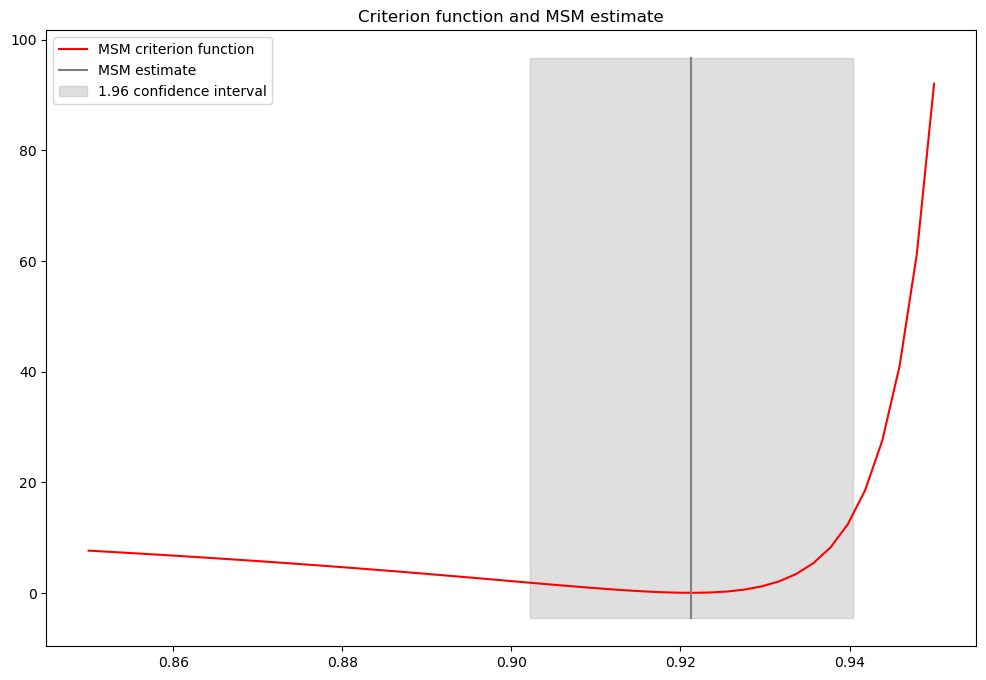

In [36]:
beta_hat = run_MSM()  # initial run with default identity weighting matrix

C:\Users\NBtestbruker1\AppData\Local\Temp\ipykernel_8076\925630666.py:39: DeprecationWarning: scipy.misc.derivative is deprecated in SciPy v1.10.0; and will be completely removed in SciPy v1.12.0. You may consider using findiff: https://github.com/maroba/findiff or numdifftools: https://github.com/pbrod/numdifftools
  D = derivative(mean_conditions,theta_hat,dx=1e-10)  # Jacobian of moment conditions


MSM estimate       : 0.91880
StdErr of estimate : 0.03720
Confidence interval: (0.84588,0.99171)


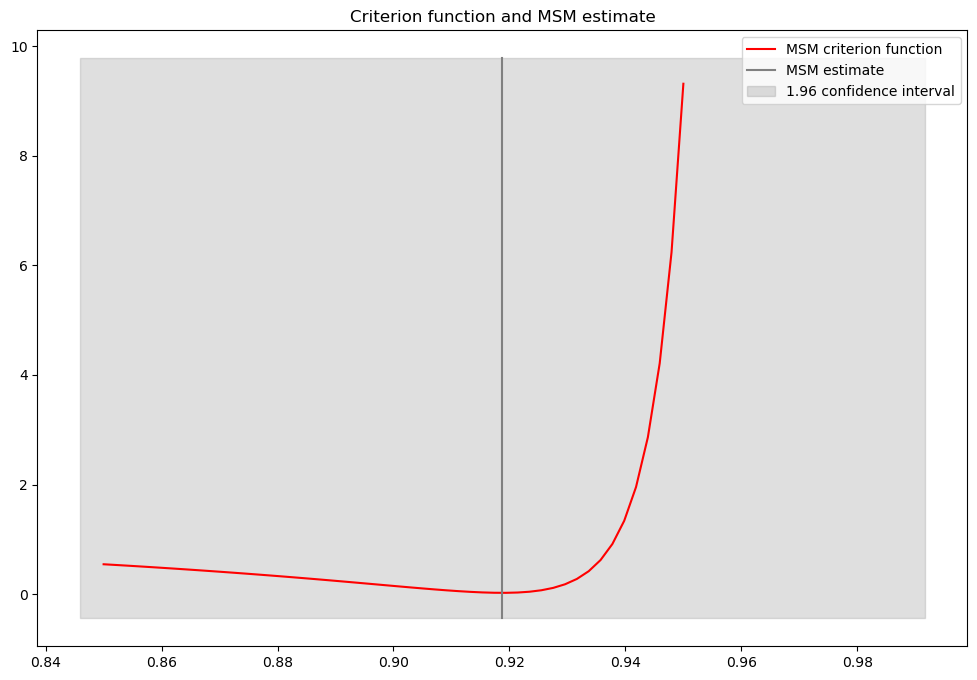

In [37]:
# Second stage MSM
moms = moment_conditions(beta_hat,data_moments_vec,seed=515)  # simulate a separate set of moment conditions
S = np.cov(np.array(moms))                                    # variance-covariance matrix of moment conditions
W1 = np.linalg.inv(S)                                         # unpdated weighting matrix
beta_hat_2 = run_MSM(W=W1)